# 10k Occupancy Investigation

Investigate why there is a drop in counts in S-phase. Is this a modeling/numerical issue?


In [206]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [366]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 3
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, (100000, 105000), log=False)


In [371]:
adapted_G = genome_deconvolution.combined_model.G.copy()

In [498]:
offset = 1
genome_deconvolution.combined_model.deconvolve(G=adapted_G+offset)

Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 13000)
Deconvolving with gamma=0.0066
0/13000 - 00:00:00.086
500/13000 - 00:00:41.588
1000/13000 - 00:01:22.325
1500/13000 - 00:02:02.596
2000/13000 - 00:02:42.964
2500/13000 - 00:03:22.790
3000/13000 - 00:04:02.991
3500/13000 - 00:04:43.559
4000/13000 - 00:05:23.655
4500/13000 - 00:06:04.129
5000/13000 - 00:06:42.794
5500/13000 - 00:07:21.419
6000/13000 - 00:08:01.799
6500/13000 - 00:08:41.857
7000/13000 - 00:09:22.549
7500/13000 - 00:10:06.273
8000/13000 - 00:10:47.737
8500/13000 - 00:11:28.550
9000/13000 - 00:12:07.353
9500/13000 - 00:12:50.231
10000/13000 - 00:13:29.880
10500/13000 - 00:14:09.761
11000/13000 - 00:14:48.191
11500/13000 - 00:15:26.388
12000/13000 - 00:16:04.977
12500/13000 - 00:16:43.673
Deconvolved in : 00:17:25.781
The fitting norm is 1.13, the smoothing norm is: 9.36


In [499]:
# Debug the drop off from G1 to S, can we identify the reasoning? Is it numerical?
# Is it resolvable?

f = genome_deconvolution.combined_model.deconvolved_f_value.copy()

In [500]:
from src.config import load_configs_by_config_type
config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')
s_indices = config.get_Hpositions_for_phase('S')

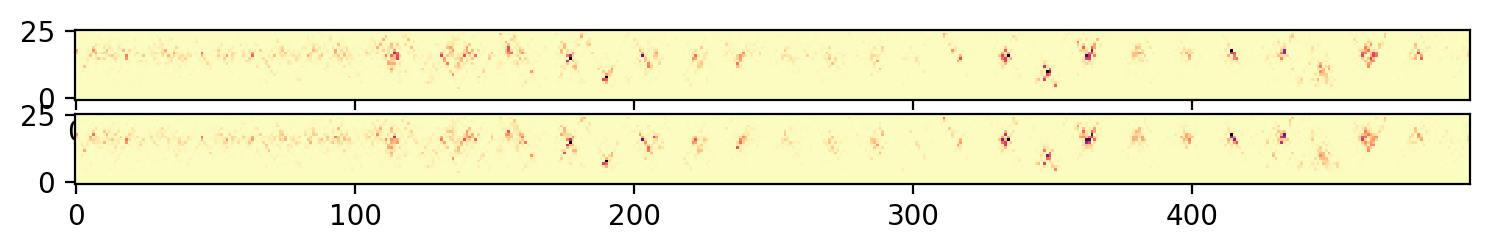

In [501]:

plt.figure(figsize=(9, 1))
plt.subplot(2, 1, 1)
plt.imshow(f[t_indices[s_indices[0]-5], :].reshape(combined_model.chrom1_model.image_shape), cmap='magma_r', 
           origin='lower', interpolation='none', vmin=offset, vmax=30, aspect='auto')

plt.subplot(2, 1, 2)
plt.imshow(f[t_indices[s_indices[-1]], :].reshape(combined_model.chrom1_model.image_shape), cmap='magma_r', 
           origin='lower', interpolation='none', vmin=offset, vmax=30, aspect='auto')

0

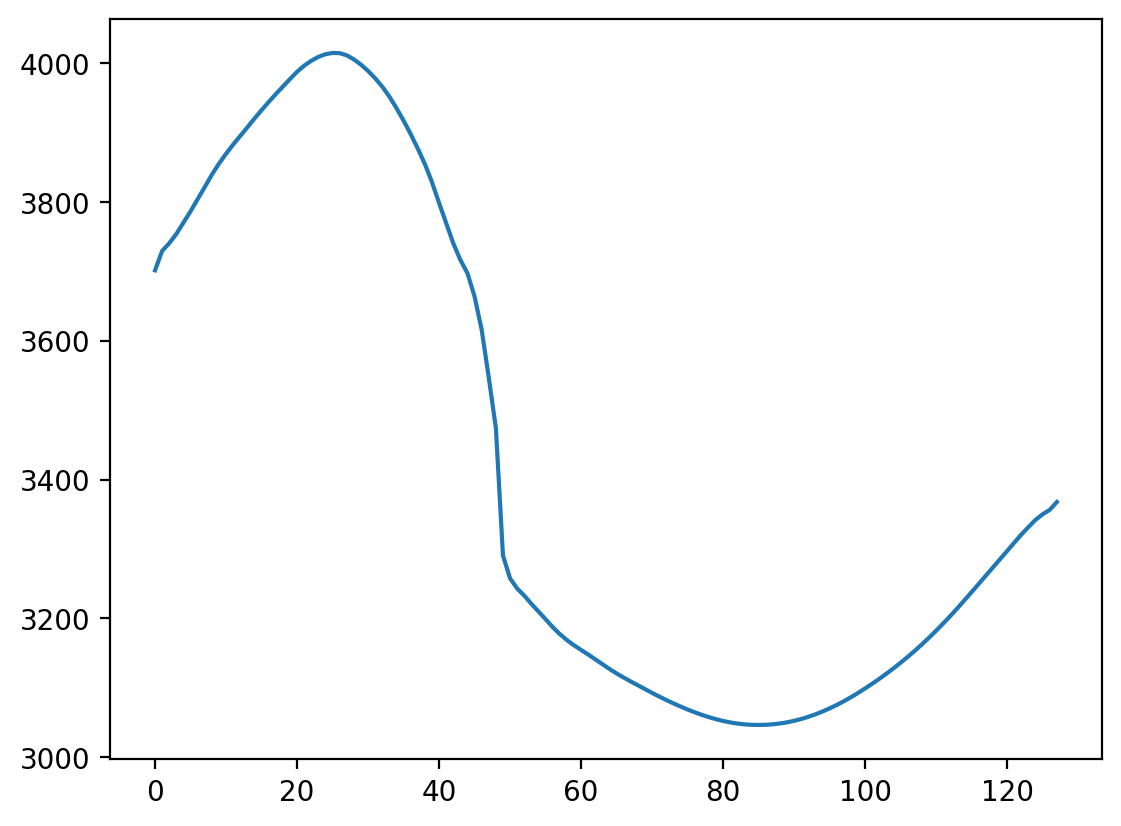

In [502]:
plt.plot((f[t_indices, :]-1).sum(axis=1))

0

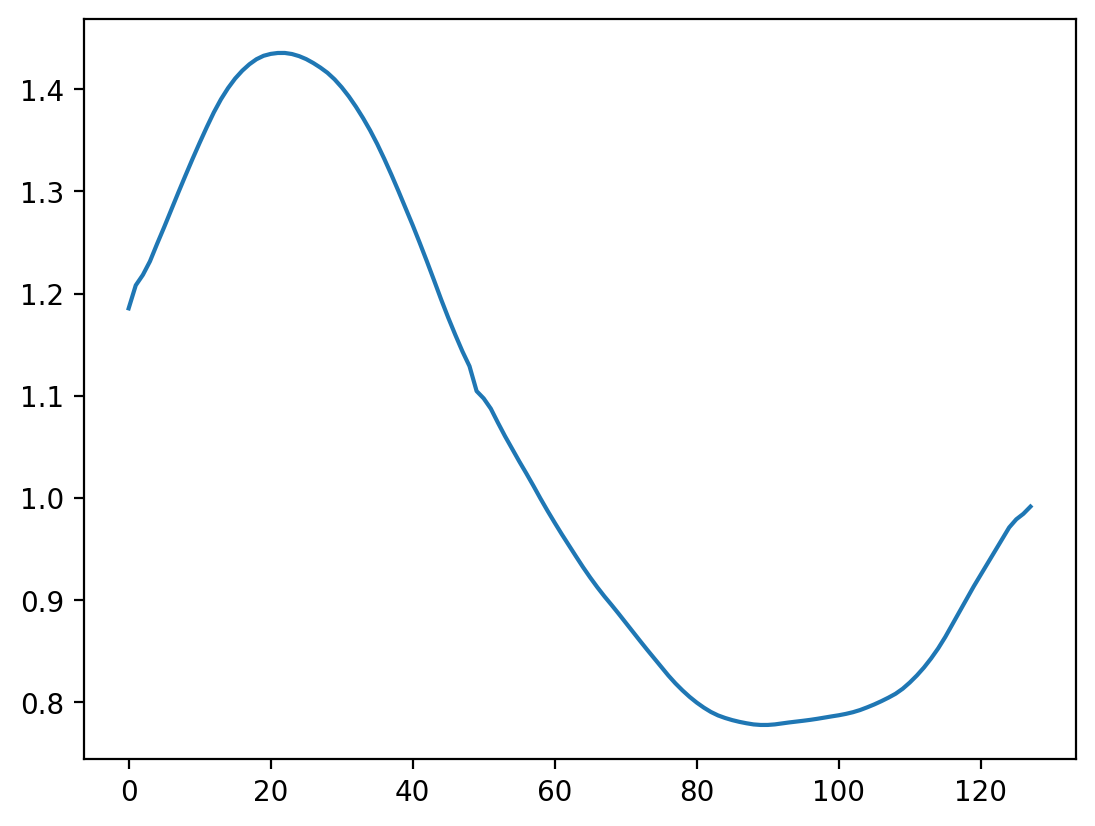

In [508]:
plt.plot(f[t_indices, 8000])

0

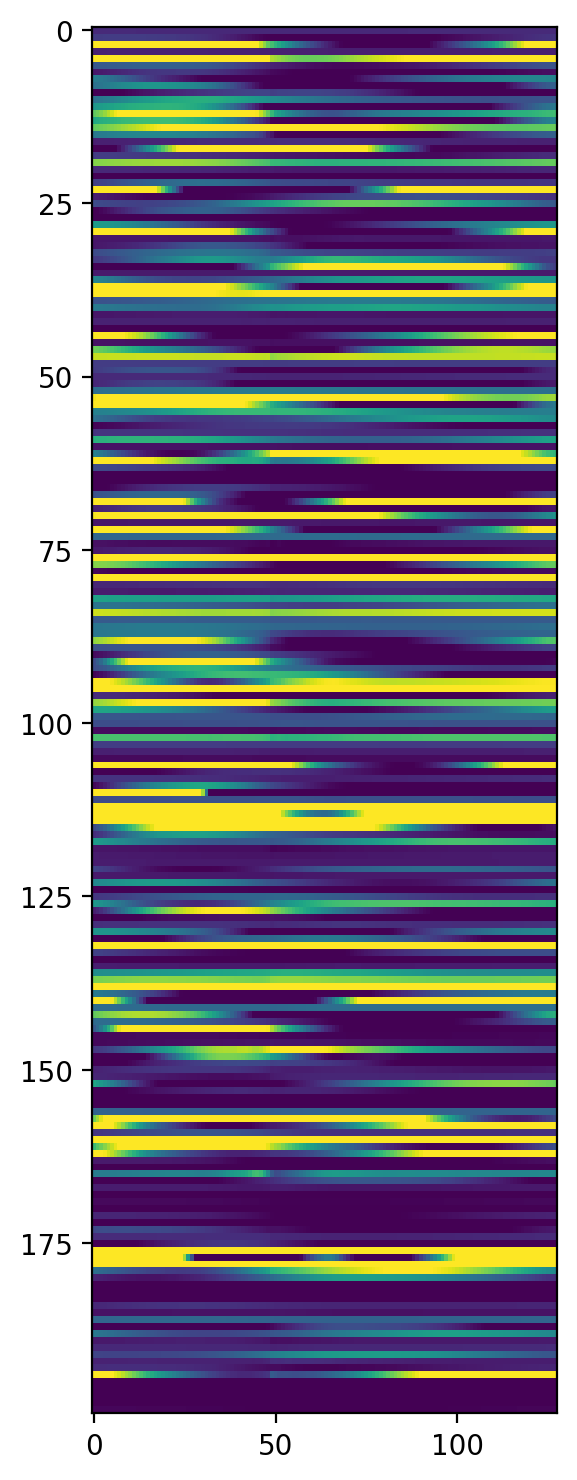

In [514]:
plt.figure(figsize=(3, 9))
plt.imshow(f[t_indices, 7000:7200].T, aspect='auto', 
           vmax=2, vmin=1, interpolation='none')

0

In [505]:
combined_model = genome_deconvolution.combined_model
old_G = combined_model.G

In [506]:
combined_model.deconvolve(G=old_G[:, 7000:7011])

Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 11)
Deconvolving with gamma=0.0066
0/11 - 00:00:00.087
Deconvolved in : 00:00:02.040
The fitting norm is 1.47, the smoothing norm is: 12.10


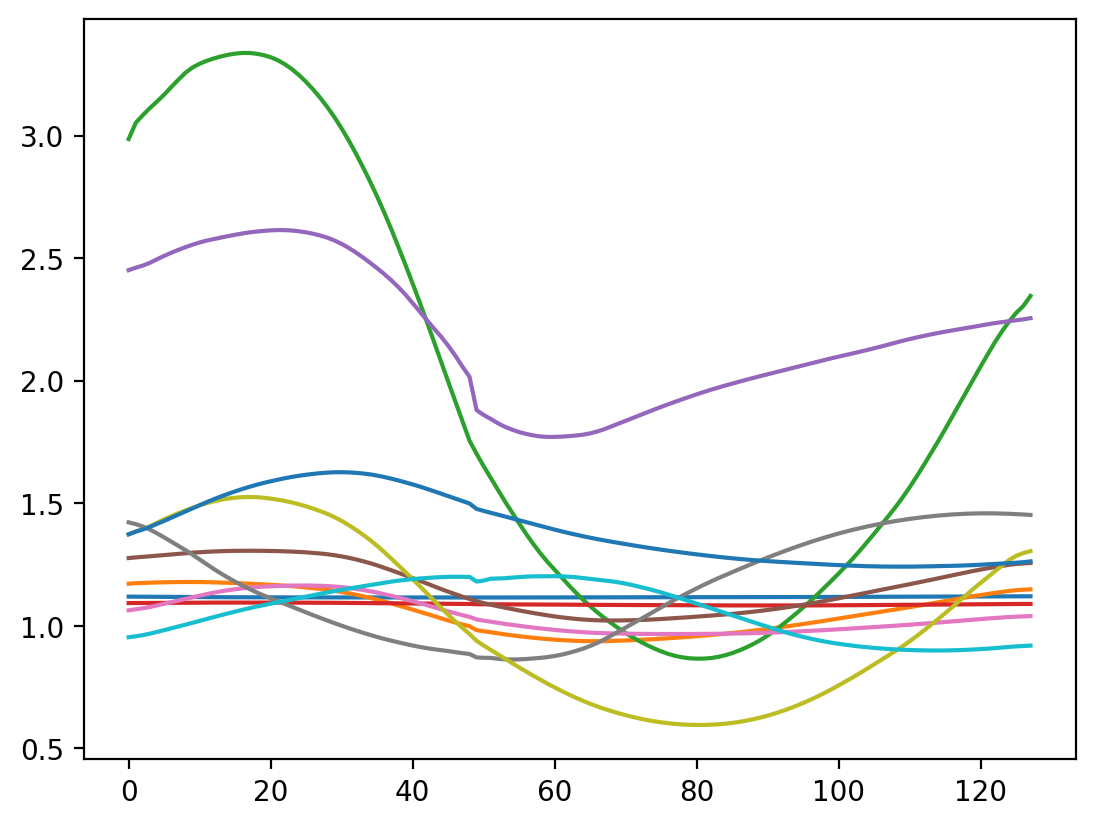

In [507]:
plt.plot(combined_model.deconvolved_f_value[t_indices])